# Series and Convergence

**This notebook teaches series from scratch, no prior exposure is assumed.**

To walk to a wall, you first cover half the distance, then half of what remains, then half again, infinitely many steps, yet you still arrive. How can adding up *infinitely many* positive numbers give a *finite* total? (This is **Zeno's paradox**.) The resolution is the mathematics of **series**, sums of long or endless lists of terms. This notebook builds series with simple loops, finds famous closed-form sums, and shows exactly when an infinite series settles onto a finite value.

## Learning objectives

- Read and expand **summation notation** $\sum$.
- Compute partial sums with a simple running-total loop.
- Recognize named finite sums (first $n$ naturals, odds, evens).
- Tell an **arithmetic** series from a **geometric** one and state when a geometric series **converges**.

## Background

A **series** is the sum of a list of terms, finite or infinite. Given terms $a_1, a_2, \dots, a_n$, the series is $S = a_1 + a_2 + \cdots + a_n$, written compactly with the summation symbol:

$$\sum_{i=1}^{n} a_i = a_1 + a_2 + \cdots + a_n,$$

where $i$ is the **index** (starting at 1 and increasing by 1), and $a_i$ is the general term. An **arithmetic** series adds a constant each step; a **geometric** series multiplies by a constant ratio $r$ each step. A geometric series with $|r| < 1$ **converges** to a finite limit:

$$\sum_{i=0}^{\infty} a\, r^{i} = \frac{a}{1 - r} \quad (|r| < 1).$$

## This notebook covers

1. Summation notation as a loop.
2. Named finite sums.
3. Arithmetic vs geometric partial sums.
4. Convergence (and why $0.999\ldots = 1$).
5. Animating the approach to a limit.
6. How the ratio $r$ decides convergence.
7. Application: drug half-life.

**Prerequisites:** none, this notebook starts from scratch.

**Dataset:** none, all terms come from formulas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

## 1. Summation notation is just a loop

The symbol $\sum_{i=1}^{n}$ means "add these up as $i$ goes from $1$ to $n$." A running-total loop does exactly that: start at zero and keep adding the next term.

In [2]:
# Add 1 + 2 + ... + 10 with a running total.
total = 0
for i in range(1, 11):
    total = total + i     # add the next term
print("1 + 2 + ... + 10 =", total)

1 + 2 + ... + 10 = 55


## 2. Named finite sums

Some sums come up so often they have closed-form formulas (a formula that skips the loop). Three classics:

$$\sum_{i=1}^{n} i = \frac{n(n+1)}{2}, \qquad \sum_{i=1}^{n} (2i-1) = n^2, \qquad \sum_{i=1}^{n} 2i = n(n+1).$$

In words: the first $n$ counting numbers sum to $n(n+1)/2$; the first $n$ **odd** numbers sum to a perfect square $n^2$; the first $n$ **even** numbers sum to $n(n+1)$. We check each formula against a direct loop.

In [3]:
n = 10

# Add the terms directly with loops...
sum_naturals = 0
sum_odds = 0
sum_evens = 0
for i in range(1, n + 1):
    sum_naturals = sum_naturals + i
    sum_odds = sum_odds + (2 * i - 1)
    sum_evens = sum_evens + (2 * i)

# ...and compare to the closed-form formulas.
print("naturals: loop =", sum_naturals, " formula n(n+1)/2 =", n * (n + 1) // 2)
print("odds:     loop =", sum_odds,     " formula n^2       =", n ** 2)
print("evens:    loop =", sum_evens,    " formula n(n+1)    =", n * (n + 1))

naturals: loop = 55  formula n(n+1)/2 = 55
odds:     loop = 100  formula n^2       = 100
evens:    loop = 110  formula n(n+1)    = 110


Loop and formula agree in every case. (The odd-number result is a neat one: $1+3+5+\cdots+(2n-1)$ is always a perfect square.)

## 3. Arithmetic vs geometric partial sums

A **partial sum** is the running total after the first few terms. We record it after each term so we can watch it grow. Here we compare an **arithmetic** series (add $1$ each step) with a **geometric** one (multiply by $r = 0.5$ each step).

In [4]:
n_terms = 15

# Geometric series: a, a*r, a*r^2, ...   (a = 1, r = 0.5)
a = 1.0
r = 0.5
geometric_partials = []
total = 0.0
for k in range(n_terms):
    total = total + a * (r ** k)   # add the next term
    geometric_partials.append(total)

# Arithmetic series: 1, 2, 3, ...   (add d = 1 each step)
arithmetic_partials = []
total = 0.0
value = 1.0
for k in range(n_terms):
    total = total + value          # add the next term
    arithmetic_partials.append(total)
    value = value + 1.0

print("geometric: ", [round(s, 4) for s in geometric_partials[:6]], "...")
print("arithmetic:", arithmetic_partials[:6], "...")

geometric:  [1.0, 1.5, 1.75, 1.875, 1.9375, 1.9688] ...
arithmetic: [1.0, 3.0, 6.0, 10.0, 15.0, 21.0] ...


## 4. Convergence (and why 0.999… = 1)

The geometric partial sums flatten toward a **limit**; the arithmetic ones grow without bound. For a geometric series with $|r| < 1$, the limit is $\dfrac{a}{1-r}$. Two famous cases:

$$\sum_{i=0}^{\infty} \frac{1}{2^{i}} = \frac{1}{1 - \tfrac12} = 2, \qquad \sum_{i=1}^{\infty} \frac{9}{10^{i}} = 0.9 + 0.09 + 0.009 + \cdots = 0.9999\ldots = 1.$$

The second is the reason the endless decimal $0.999\ldots$ **equals** exactly $1$. We add its terms and watch the total close in on 1.

1 terms -> 0.9
2 terms -> 0.99
3 terms -> 0.999
4 terms -> 0.9999
5 terms -> 0.99999
6 terms -> 0.9999990000000001
limit a/(1-r) with a=0.9, r=0.1 = 1.0
sum of 1/2^i approaches: 2.0


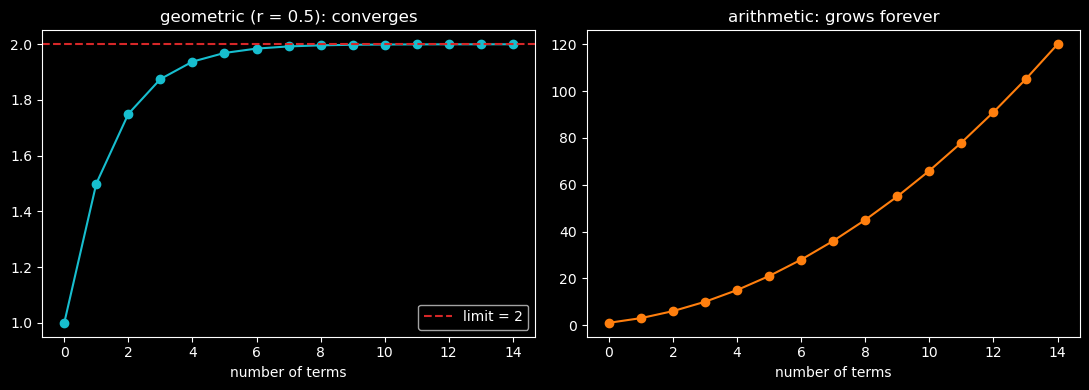

In [5]:
# 0.999... = sum of 9/10 + 9/100 + 9/1000 + ...
total = 0.0
for i in range(1, 16):
    total = total + 9 / (10 ** i)   # add the next 9-digit
    if i <= 6:
        print(i, "terms ->", total)
print("limit a/(1-r) with a=0.9, r=0.1 =", 0.9 / (1 - 0.1))

# geometric limit for the 1/2^i series
print("sum of 1/2^i approaches:", 1.0 / (1 - 0.5))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(n_terms), geometric_partials, "o-", color="tab:cyan")
axes[0].axhline(2.0, color="tab:red", ls="--", label="limit = 2")
axes[0].set_title("geometric (r = 0.5): converges")
axes[0].set_xlabel("number of terms"); axes[0].legend()
axes[1].plot(range(n_terms), arithmetic_partials, "o-", color="tab:orange")
axes[1].set_title("arithmetic: grows forever")
axes[1].set_xlabel("number of terms")
plt.tight_layout()
plt.show()

The geometric partial sums pile up just under the dashed limit and never pass it, they **converge**. The arithmetic sums keep climbing, they **diverge**. And $0.999\ldots$ is simply a geometric series whose limit is exactly $1$.

## 5. Animating the approach

Each frame adds one more term, so the running total steps a little closer to the limit.

*(The animation code is plotting machinery, you can ignore it; watch the total approach the dashed line.)*

In [6]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(2.0, color="tab:red", ls="--", label="limit")
ax.set_xlim(0, n_terms)
ax.set_ylim(0, 2.2)
ax.set_xlabel("number of terms"); ax.set_ylabel("partial sum"); ax.legend()
line, = ax.plot([], [], "o-", color="tab:cyan")

def update(frame):
    line.set_data(range(frame + 1), geometric_partials[:frame + 1])
    return (line,)

ani = FuncAnimation(fig, update, frames=n_terms, interval=300, blit=True)
plt.close(fig)   # hide the static duplicate
HTML(ani.to_jshtml())

## 6. The ratio r decides everything

If $|r| < 1$ the terms shrink and the sum converges; if $|r| \ge 1$ the terms do not shrink and the sum runs away. Try different ratios with the slider.

In [7]:
from ipywidgets import interact

def show_geometric(r=0.5):
    a = 1.0
    partials = []
    total = 0.0
    for k in range(20):
        total = total + a * (r ** k)   # add the next term
        partials.append(total)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(20), partials, "o-", color="tab:cyan")
    if abs(r) < 1:
        ax.axhline(a / (1 - r), color="tab:red", ls="--", label="limit")
        ax.legend()
    ax.set_title("geometric series, r = " + str(round(r, 2)))
    ax.set_xlabel("number of terms")
    plt.show()

interact(show_geometric, r=(-1.5, 1.5, 0.1));

interactive(children=(FloatSlider(value=0.5, description='r', max=1.5, min=-1.5), Output()), _dom_classes=('wi…

## 7. Application: drug half-life

Half-life problems are geometric series with $r = 0.5$. Suppose a dose puts 100 mg in the body and each period the amount left is halved. The **total exposure** over many periods is the series sum.

In [8]:
dose = 100.0     # mg
r = 0.5          # half remains each period

total_exposure = 0.0
amount = dose
for period in range(10):
    total_exposure = total_exposure + amount   # add this period's amount
    amount = amount * r                        # half remains next period

print("total exposure over 10 periods:", round(total_exposure, 2), "mg-periods")
print("theoretical limit dose/(1-r)  =", dose / (1 - r), "mg-periods")

total exposure over 10 periods: 199.8 mg-periods
theoretical limit dose/(1-r)  = 200.0 mg-periods


## 8. Summary

- A **series** sums a list of terms; **summation notation** $\sum$ is shorthand for a running-total loop.
- Named finite sums: $\sum i = \tfrac{n(n+1)}{2}$, $\sum (2i-1) = n^2$, $\sum 2i = n(n+1)$.
- **Geometric** series converge to $\tfrac{a}{1-r}$ when $|r|<1$; **arithmetic** series grow without bound.
- $0.999\ldots = 1$ is a geometric series in disguise; half-life problems use $r = 0.5$.

Next: what happens to all of this arithmetic when a computer, with only finitely many digits,
has to do it (`U1-5_FloatingPoint-1_MachineEpsilon`).